# 02 — Imbalance Analysis

This notebook systematically evaluates six imbalance mitigation strategies on the CICIoT2023 dataset.
All strategies are benchmarked with a `DecisionTreeClassifier` probe model on the validation set.
The winning strategy (by macro F1) is carried forward to notebook 03 for ensemble training.

## §1 Setup & Imports

This notebook analyzes class imbalance and evaluates mitigation strategies.
A `DecisionTreeClassifier` is used as the probe model throughout — it is fast
enough to compare many strategies without the overhead of ensemble methods,
which are the subject of notebook 03. The evaluation metric is **macro F1**,
which weights all classes equally regardless of size. Accuracy is explicitly
avoided as the primary metric: with ~75% DDoS dominance a model predicting only
DDoS achieves 75% accuracy yet zero useful recall on minority classes.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score, matthews_corrcoef
)
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED          = 42
PROCESSED_DIR = Path('../data/processed')
CLASS_NAMES   = ['Benign', 'BruteForce', 'DDoS', 'DoS', 'Mirai', 'Recon', 'Spoofing', 'Web-based']

train = pd.read_parquet(PROCESSED_DIR / 'train.parquet')
val   = pd.read_parquet(PROCESSED_DIR / 'val.parquet')
test  = pd.read_parquet(PROCESSED_DIR / 'test.parquet')

X_train = train.drop(columns='y').values
y_train = train['y'].values
X_val   = val.drop(columns='y').values
y_val   = val['y'].values
X_test  = test.drop(columns='y').values
y_test  = test['y'].values

print(f'Train : {X_train.shape},  y: {y_train.shape}')
print(f'Val   : {X_val.shape},  y: {y_val.shape}')
print(f'Test  : {X_test.shape},  y: {y_test.shape}')

results = []  # accumulates one dict per strategy


def evaluate(model, X, y):
    y_pred = model.predict(X)
    return {
        'Accuracy': accuracy_score(y, y_pred),
        'Macro F1': f1_score(y, y_pred, average='macro', zero_division=0),
        'Macro P':  precision_score(y, y_pred, average='macro', zero_division=0),
        'Macro R':  recall_score(y, y_pred, average='macro', zero_division=0),
        'MCC':      matthews_corrcoef(y, y_pred),
        'y_pred':   y_pred,
    }


def print_metrics(m):
    acc, f1 = m['Accuracy'], m['Macro F1']
    p, r, mcc = m['Macro P'], m['Macro R'], m['MCC']
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Macro F1 : {f1:.4f}  <- headline metric')
    print(f'  Macro P  : {p:.4f}')
    print(f'  Macro R  : {r:.4f}')
    print(f'  MCC      : {mcc:.4f}')


def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    fig, ax = plt.subplots(figsize=(9, 7), dpi=100)
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True', fontsize=12)
    ax.set_title(title, fontsize=13)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


def show_resampled_dist(resampler, X, y):
    _, y_res = resampler.fit_resample(X, y)
    total = len(y_res)
    print('  Class              Count      Pct')
    print('  ' + '-' * 35)
    for i, name in enumerate(CLASS_NAMES):
        n = int((y_res == i).sum())
        pct = n / total
        print(f'  {name:<15} {n:>9,} {pct:>8.2%}')
    print(f'  Total          {total:>9,}')

Train : (699626, 39),  y: (699626,)
Val   : (149920, 39),  y: (149920,)
Test  : (149920, 39),  y: (149920,)


## §2 Baseline — No Mitigation

The baseline establishes what happens with no imbalance handling.
Expected behaviour: near-perfect recall for DDoS and DoS (majority classes),
near-zero recall for BruteForce and Web-based (minority classes).
The gap between accuracy and macro F1 quantifies the severity of the imbalance problem.

  Accuracy : 0.9942
  Macro F1 : 0.8144  <- headline metric
  Macro P  : 0.8113
  Macro R  : 0.8177
  MCC      : 0.9852

              precision    recall  f1-score   support

      Benign       0.92      0.91      0.91      3650
  BruteForce       0.43      0.46      0.44        26
        DDoS       1.00      1.00      1.00    113416
         DoS       1.00      1.00      1.00     26997
       Mirai       1.00      1.00      1.00      2966
       Recon       0.79      0.80      0.79      1166
    Spoofing       0.84      0.85      0.85      1623
   Web-based       0.51      0.53      0.52        76

    accuracy                           0.99    149920
   macro avg       0.81      0.82      0.81    149920
weighted avg       0.99      0.99      0.99    149920



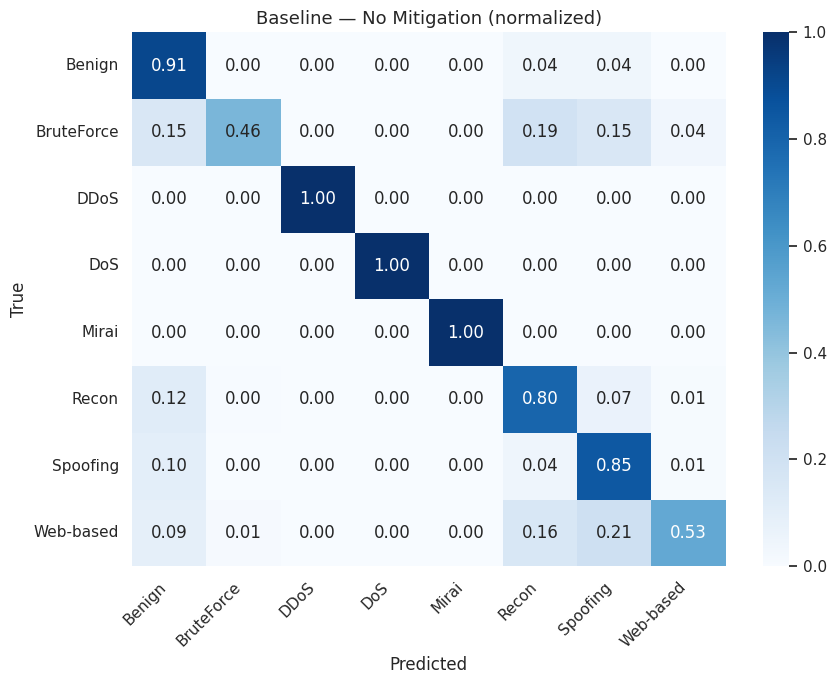

In [2]:
dt_base = DecisionTreeClassifier(random_state=SEED)
dt_base.fit(X_train, y_train)

m_base = evaluate(dt_base, X_val, y_val)
m_base['Strategy'] = 'Baseline'
results.append(m_base)

print_metrics(m_base)
print()
print(classification_report(y_val, m_base['y_pred'], target_names=CLASS_NAMES, zero_division=0))
plot_cm(y_val, m_base['y_pred'], 'Baseline — No Mitigation (normalized)')

## §3 Class Distribution Visualization

Log scale is necessary to make minority classes visible — on linear scale
BruteForce (~118 samples) is invisible next to DDoS (~529,275).
The `ratio_vs_majority` column quantifies how underrepresented each class is.

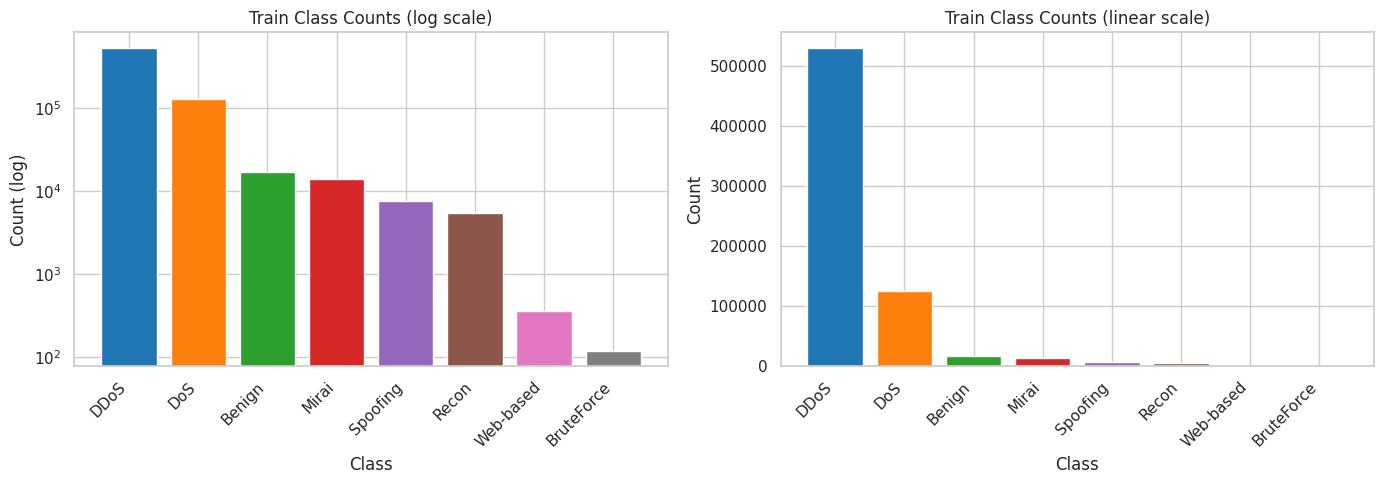

Imbalance ratio (max/min): 4485.4:1

  Class             Count         Pct  Ratio vs Majority
  ------------------------------------------------------
  DDoS               529,274  75.6510%                1.0x
  DoS                125,990  18.0082%                4.2x
  Benign              17,035   2.4349%               31.1x
  Mirai               13,841   1.9783%               38.2x
  Spoofing             7,571   1.0821%               69.9x
  Recon                5,442   0.7778%               97.3x
  Web-based              355   0.0507%             1490.9x
  BruteForce             118   0.0169%             4485.4x


In [3]:
counts = pd.Series(
    {CLASS_NAMES[i]: int((y_train == i).sum()) for i in range(len(CLASS_NAMES))}
).sort_values(ascending=False)

majority_count = counts.max()
minority_count = counts.min()
palette = sns.color_palette('tab10', len(counts))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

axes[0].bar(counts.index, counts.values, color=palette)
axes[0].set_yscale('log')
axes[0].set_title('Train Class Counts (log scale)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count (log)')
axes[0].set_xticks(range(len(counts)))
axes[0].set_xticklabels(counts.index, rotation=45, ha='right')

axes[1].bar(counts.index, counts.values, color=palette)
axes[1].set_title('Train Class Counts (linear scale)')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(len(counts)))
axes[1].set_xticklabels(counts.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

imbalance_ratio = majority_count / minority_count
print(f'Imbalance ratio (max/min): {imbalance_ratio:.1f}:1\n')

print('  Class             Count         Pct  Ratio vs Majority')
print('  ' + '-' * 54)
for cls, n in counts.items():
    pct   = n / len(y_train)
    ratio = majority_count / n
    print(f'  {cls:<15} {n:>10,} {pct:>9.4%} {ratio:>18.1f}x')

## §4 Strategy 1 — class_weight='balanced'

`class_weight='balanced'` assigns each class a weight inversely proportional
to its frequency: `weight[c] = n_samples / (n_classes × count[c])`.
No new samples are created — the decision boundary shifts to penalise
misclassification of minority classes more heavily. This is the cheapest
mitigation strategy and a strong baseline for comparison.

  Accuracy : 0.9935
  Macro F1 : 0.8091  <- headline metric
  Macro P  : 0.7987
  Macro R  : 0.8248
  MCC      : 0.9836

              precision    recall  f1-score   support

      Benign       0.90      0.91      0.91      3650
  BruteForce       0.35      0.54      0.42        26
        DDoS       1.00      1.00      1.00    113416
         DoS       1.00      1.00      1.00     26997
       Mirai       1.00      1.00      1.00      2966
       Recon       0.80      0.79      0.80      1166
    Spoofing       0.85      0.82      0.83      1623
   Web-based       0.49      0.54      0.52        76

    accuracy                           0.99    149920
   macro avg       0.80      0.82      0.81    149920
weighted avg       0.99      0.99      0.99    149920



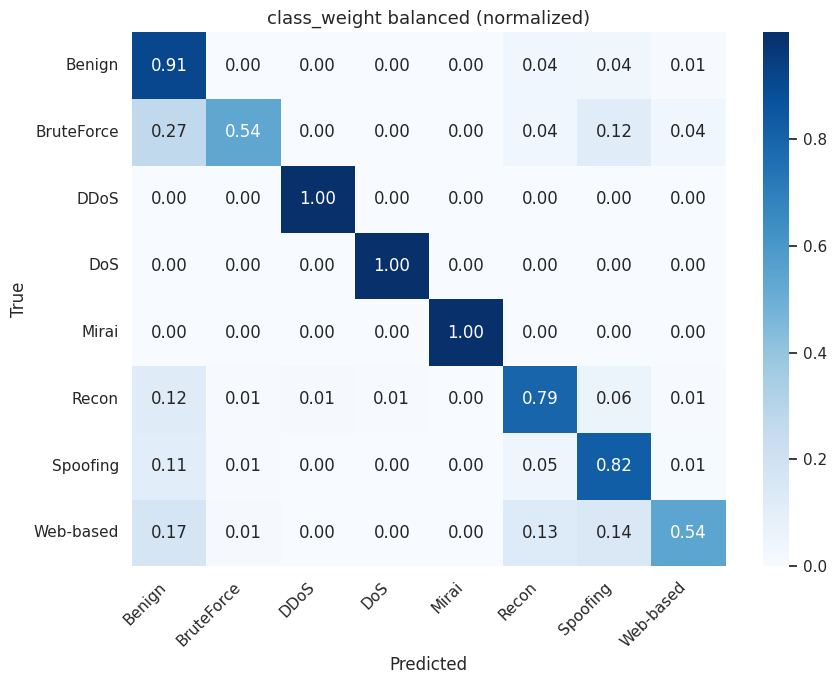

In [4]:
dt_balanced = DecisionTreeClassifier(class_weight='balanced', random_state=SEED)
dt_balanced.fit(X_train, y_train)

m_balanced = evaluate(dt_balanced, X_val, y_val)
m_balanced['Strategy'] = 'class_weight=balanced'
results.append(m_balanced)

print_metrics(m_balanced)
print()
print(classification_report(y_val, m_balanced['y_pred'], target_names=CLASS_NAMES, zero_division=0))
plot_cm(y_val, m_balanced['y_pred'], 'class_weight balanced (normalized)')

## §5 Strategy 2 — RandomOverSampler

`RandomOverSampler` duplicates existing minority-class samples randomly until
all classes reach the majority class size. It is fast and introduces no
synthetic data, but risks overfitting: the duplicated samples are identical
to existing ones, so the model may memorize rather than generalize.
`ImbPipeline` ensures resampling is applied only to the training set —
never to val or test (which would constitute data leakage).

Resampled class distribution:
  Class              Count      Pct
  -----------------------------------
  Benign            529,274   12.50%
  BruteForce        529,274   12.50%
  DDoS              529,274   12.50%
  DoS               529,274   12.50%
  Mirai             529,274   12.50%
  Recon             529,274   12.50%
  Spoofing          529,274   12.50%
  Web-based         529,274   12.50%
  Total          4,234,192

  Accuracy : 0.9936
  Macro F1 : 0.8247  <- headline metric
  Macro P  : 0.8233
  Macro R  : 0.8263
  MCC      : 0.9839

              precision    recall  f1-score   support

      Benign       0.91      0.91      0.91      3650
  BruteForce       0.54      0.54      0.54        26
        DDoS       1.00      1.00      1.00    113416
         DoS       1.00      1.00      1.00     26997
       Mirai       1.00      1.00      1.00      2966
       Recon       0.80      0.79      0.79      1166
    Spoofing       0.83      0.82      0.83      1623
   Web-based      

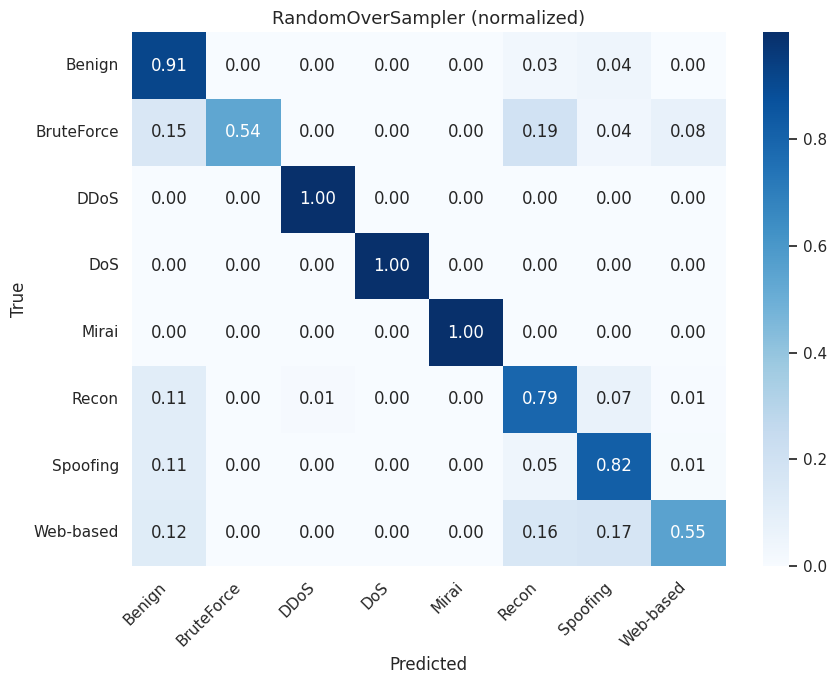

In [5]:
print('Resampled class distribution:')
show_resampled_dist(RandomOverSampler(random_state=SEED), X_train, y_train)
print()

pipe_ros = ImbPipeline([
    ('oversample', RandomOverSampler(random_state=SEED)),
    ('clf',        DecisionTreeClassifier(random_state=SEED)),
])
pipe_ros.fit(X_train, y_train)

m_ros = evaluate(pipe_ros, X_val, y_val)
m_ros['Strategy'] = 'RandomOverSampler'
results.append(m_ros)

print_metrics(m_ros)
print()
print(classification_report(y_val, m_ros['y_pred'], target_names=CLASS_NAMES, zero_division=0))
plot_cm(y_val, m_ros['y_pred'], 'RandomOverSampler (normalized)')

## §6 Strategy 3 — SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic samples
by interpolating between a minority sample and one of its k nearest neighbours
in feature space. Unlike `RandomOverSampler`, each new sample is a novel point —
reducing the risk of exact memorization. `k_neighbors=5` (default) requires at
least 6 samples per class; BruteForce (~118) satisfies this comfortably.
SMOTE is the standard reference technique for imbalanced classification
and is expected to outperform `RandomOverSampler` on minority recall.

Resampled class distribution:
  Class              Count      Pct
  -----------------------------------
  Benign            529,274   12.50%
  BruteForce        529,274   12.50%
  DDoS              529,274   12.50%
  DoS               529,274   12.50%
  Mirai             529,274   12.50%
  Recon             529,274   12.50%
  Spoofing          529,274   12.50%
  Web-based         529,274   12.50%
  Total          4,234,192

  Accuracy : 0.9904
  Macro F1 : 0.7527  <- headline metric
  Macro P  : 0.7437
  Macro R  : 0.7658
  MCC      : 0.9756

              precision    recall  f1-score   support

      Benign       0.87      0.89      0.88      3650
  BruteForce       0.35      0.31      0.33        26
        DDoS       1.00      1.00      1.00    113416
         DoS       1.00      1.00      1.00     26997
       Mirai       1.00      0.99      1.00      2966
       Recon       0.72      0.73      0.72      1166
    Spoofing       0.76      0.82      0.79      1623
   Web-based      

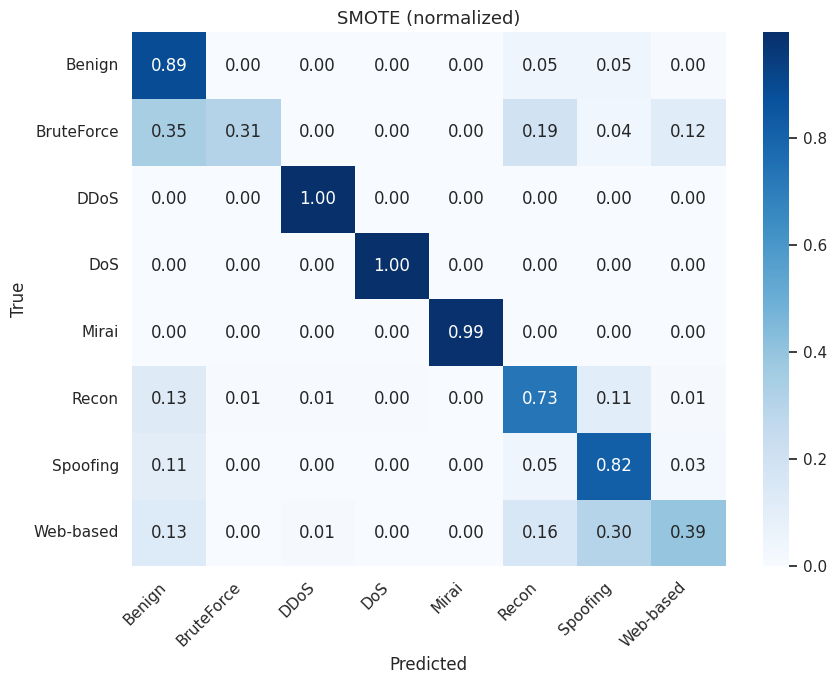

In [6]:
print('Resampled class distribution:')
show_resampled_dist(SMOTE(random_state=SEED, k_neighbors=5), X_train, y_train)
print()

pipe_smote = ImbPipeline([
    ('oversample', SMOTE(random_state=SEED, k_neighbors=5)),
    ('clf',        DecisionTreeClassifier(random_state=SEED)),
])
pipe_smote.fit(X_train, y_train)

m_smote = evaluate(pipe_smote, X_val, y_val)
m_smote['Strategy'] = 'SMOTE'
results.append(m_smote)

print_metrics(m_smote)
print()
print(classification_report(y_val, m_smote['y_pred'], target_names=CLASS_NAMES, zero_division=0))
plot_cm(y_val, m_smote['y_pred'], 'SMOTE (normalized)')

## §7 Strategy 4 — ADASYN

ADASYN (Adaptive Synthetic Sampling) extends SMOTE by generating more synthetic
samples in regions of feature space where minority samples are harder to classify
(i.e., surrounded by majority-class neighbours). It adapts the density of
synthetic generation to the local difficulty, which can improve performance on
hard-to-classify boundary samples — relevant for Web-based and BruteForce whose
feature distributions overlap with majority classes.

  Accuracy : 0.9909
  Macro F1 : 0.7538  <- headline metric
  Macro P  : 0.7460
  Macro R  : 0.7639
  MCC      : 0.9770

              precision    recall  f1-score   support

      Benign       0.88      0.89      0.89      3650
  BruteForce       0.26      0.23      0.24        26
        DDoS       1.00      1.00      1.00    113416
         DoS       1.00      1.00      1.00     26997
       Mirai       1.00      1.00      1.00      2966
       Recon       0.73      0.73      0.73      1166
    Spoofing       0.77      0.82      0.79      1623
   Web-based       0.34      0.45      0.39        76

    accuracy                           0.99    149920
   macro avg       0.75      0.76      0.75    149920
weighted avg       0.99      0.99      0.99    149920



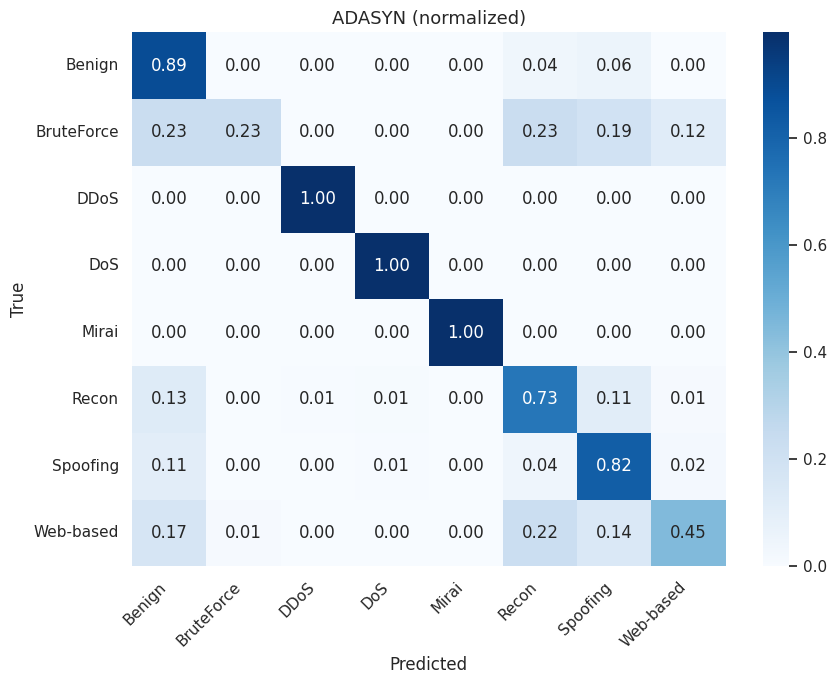

In [7]:
pipe_adasyn = ImbPipeline([
    ('oversample', ADASYN(random_state=SEED)),
    ('clf',        DecisionTreeClassifier(random_state=SEED)),
])
pipe_adasyn.fit(X_train, y_train)

m_adasyn = evaluate(pipe_adasyn, X_val, y_val)
m_adasyn['Strategy'] = 'ADASYN'
results.append(m_adasyn)

print_metrics(m_adasyn)
print()
print(classification_report(y_val, m_adasyn['y_pred'], target_names=CLASS_NAMES, zero_division=0))
plot_cm(y_val, m_adasyn['y_pred'], 'ADASYN (normalized)')

## §8 Strategy 5 — RandomUnderSampler

`RandomUnderSampler` removes majority-class samples randomly until all classes
reach the minority class size. The key trade-off: it dramatically reduces
training set size (from ~700K to ~944 samples given BruteForce=118),
discarding potentially useful information from majority classes.
It is included as a reference for the information-loss trade-off discussion.

Training set before undersampling: 699,626 rows
After RandomUnderSampler:
  Class              Count      Pct
  -----------------------------------
  Benign                118   12.50%
  BruteForce            118   12.50%
  DDoS                  118   12.50%
  DoS                   118   12.50%
  Mirai                 118   12.50%
  Recon                 118   12.50%
  Spoofing              118   12.50%
  Web-based             118   12.50%
  Total                944

  Accuracy : 0.9610
  Macro F1 : 0.6115  <- headline metric
  Macro P  : 0.5805
  Macro R  : 0.7946
  MCC      : 0.9052

              precision    recall  f1-score   support

      Benign       0.92      0.69      0.79      3650
  BruteForce       0.04      0.69      0.07        26
        DDoS       1.00      0.98      0.99    113416
         DoS       0.97      0.96      0.97     26997
       Mirai       0.67      0.97      0.80      2966
       Recon       0.40      0.69      0.51      1166
    Spoofing       0.55     

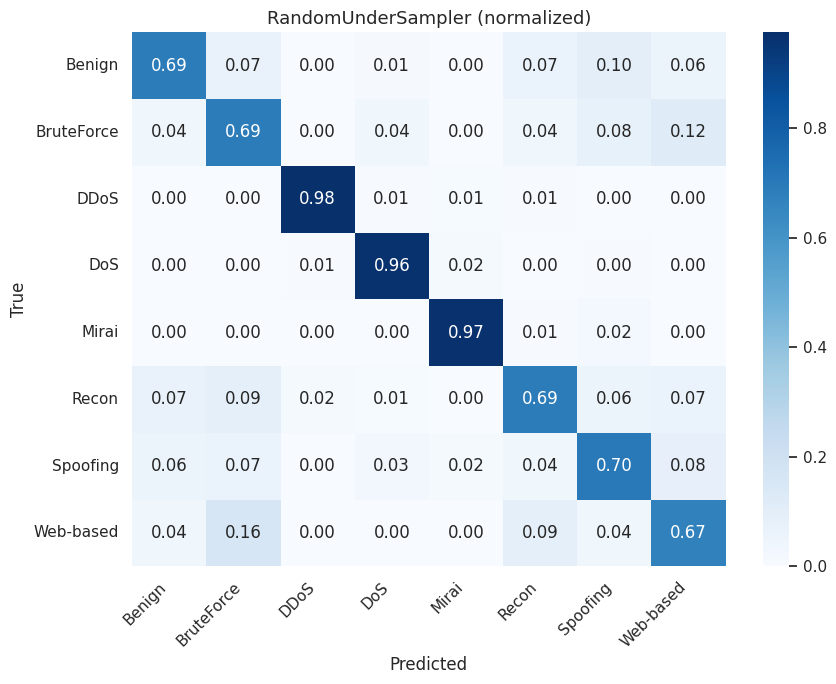

In [8]:
print(f'Training set before undersampling: {len(y_train):,} rows')
print('After RandomUnderSampler:')
show_resampled_dist(RandomUnderSampler(random_state=SEED), X_train, y_train)
print()

pipe_rus = ImbPipeline([
    ('undersample', RandomUnderSampler(random_state=SEED)),
    ('clf',         DecisionTreeClassifier(random_state=SEED)),
])
pipe_rus.fit(X_train, y_train)

m_rus = evaluate(pipe_rus, X_val, y_val)
m_rus['Strategy'] = 'RandomUnderSampler'
results.append(m_rus)

print_metrics(m_rus)
print()
print(classification_report(y_val, m_rus['y_pred'], target_names=CLASS_NAMES, zero_division=0))
plot_cm(y_val, m_rus['y_pred'], 'RandomUnderSampler (normalized)')

## §9 Strategy 6 — SMOTETomek

SMOTETomek combines oversampling (SMOTE) with cleaning (Tomek links removal).
After SMOTE generates synthetic minority samples, Tomek links — pairs of
samples from different classes that are each other's nearest neighbour —
are removed from both classes. This cleans the decision boundary, removing
majority samples that are borderline or noisy. The combination typically
produces cleaner class separation than SMOTE alone.

  Accuracy : 0.9903
  Macro F1 : 0.7518  <- headline metric
  Macro P  : 0.7421
  Macro R  : 0.7657
  MCC      : 0.9755

              precision    recall  f1-score   support

      Benign       0.88      0.89      0.88      3650
  BruteForce       0.30      0.27      0.29        26
        DDoS       1.00      1.00      1.00    113416
         DoS       1.00      1.00      1.00     26997
       Mirai       1.00      0.99      0.99      2966
       Recon       0.72      0.73      0.72      1166
    Spoofing       0.76      0.81      0.79      1623
   Web-based       0.29      0.43      0.35        76

    accuracy                           0.99    149920
   macro avg       0.74      0.77      0.75    149920
weighted avg       0.99      0.99      0.99    149920



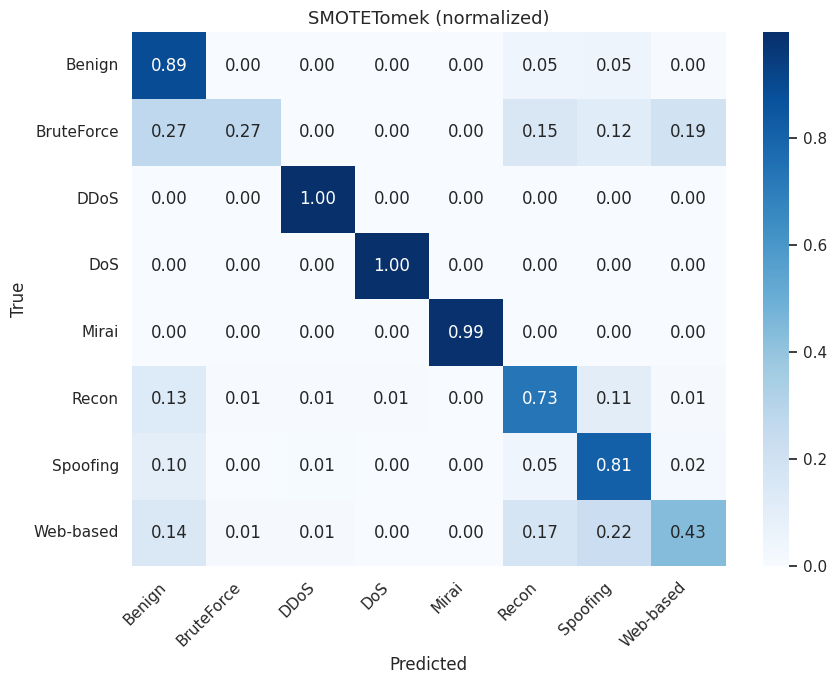

In [9]:
pipe_st = ImbPipeline([
    ('combine', SMOTETomek(random_state=SEED)),
    ('clf',     DecisionTreeClassifier(random_state=SEED)),
])
pipe_st.fit(X_train, y_train)

m_st = evaluate(pipe_st, X_val, y_val)
m_st['Strategy'] = 'SMOTETomek'
results.append(m_st)

print_metrics(m_st)
print()
print(classification_report(y_val, m_st['y_pred'], target_names=CLASS_NAMES, zero_division=0))
plot_cm(y_val, m_st['y_pred'], 'SMOTETomek (normalized)')

## §10 Comparative Results Table

The comparison table is the key output of this notebook.
The chosen strategy for notebook 03 is the one with the best macro F1 on the
validation set — not accuracy. If multiple strategies are close, prefer the one
with better recall on BruteForce and Web-based (the hardest classes).

                       Accuracy  Macro F1  Macro P  Macro R     MCC
Strategy                                                           
Baseline                 0.9942    0.8144   0.8113   0.8177  0.9852
class_weight=balanced    0.9935    0.8091   0.7987   0.8248  0.9836
RandomOverSampler        0.9936    0.8247   0.8233   0.8263  0.9839
SMOTE                    0.9904    0.7527   0.7437   0.7658  0.9756
ADASYN                   0.9909    0.7538   0.7460   0.7639  0.9770
RandomUnderSampler       0.9610    0.6115   0.5805   0.7946  0.9052
SMOTETomek               0.9903    0.7518   0.7421   0.7657  0.9755

Best Macro F1: 'RandomOverSampler'  (0.8247)



,Accuracy,Macro F1,Macro P,Macro R,MCC
Strategy,,,,,
Baseline,0.994200,0.814400,0.811300,0.817700,0.985200
class_weight=balanced,0.993500,0.809100,0.798700,0.824800,0.983600
RandomOverSampler,0.993600,0.824700,0.823300,0.826300,0.983900
SMOTE,0.990400,0.752700,0.743700,0.765800,0.975600
ADASYN,0.990900,0.753800,0.746000,0.763900,0.977000
RandomUnderSampler,0.961000,0.611500,0.580500,0.794600,0.905200
SMOTETomek,0.990300,0.751800,0.742100,0.765700,0.975500


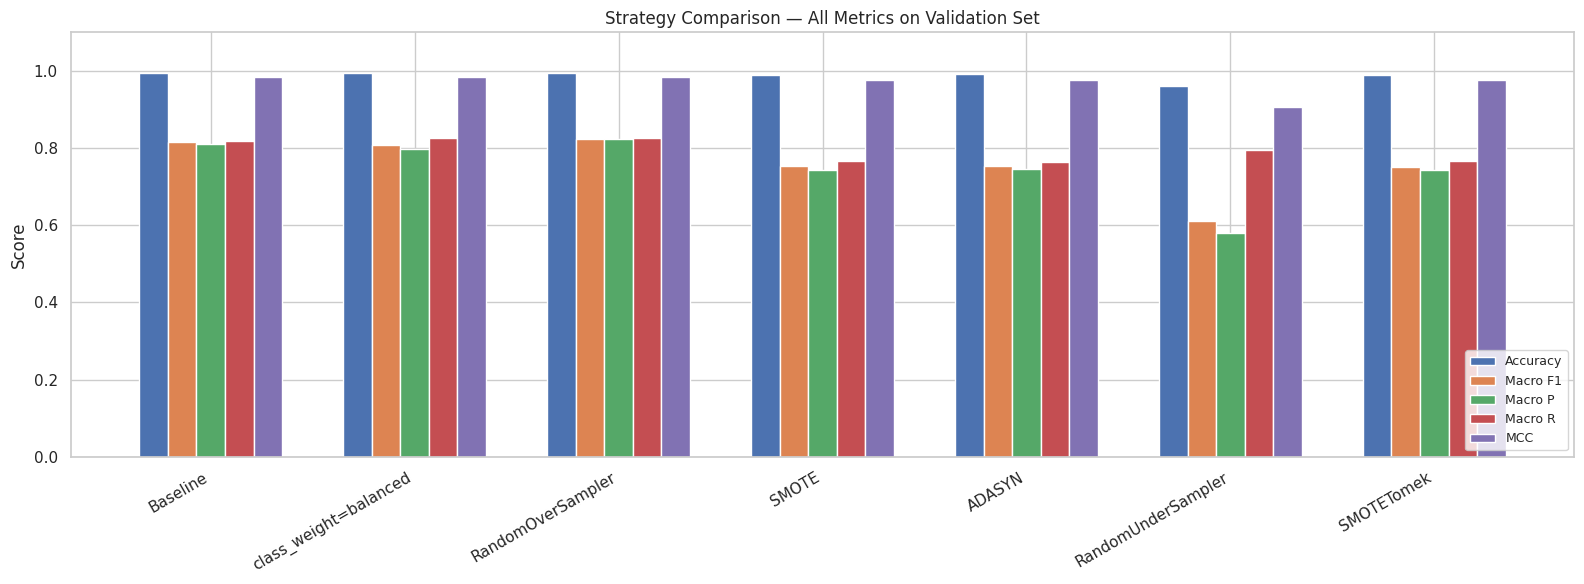

In [10]:
cols = ['Strategy', 'Accuracy', 'Macro F1', 'Macro P', 'Macro R', 'MCC']
df_results = (
    pd.DataFrame([{k: r[k] for k in cols} for r in results])
    .set_index('Strategy')
)

best_strategy = df_results['Macro F1'].idxmax()
best_f1       = df_results.loc[best_strategy, 'Macro F1']

print(df_results.round(4).to_string())
print(f'\nBest Macro F1: {best_strategy!r}  ({best_f1:.4f})')
print()

display(
    df_results.round(4)
    .style
    .highlight_max(subset=['Macro F1'], color='#d4edda')
    .highlight_min(subset=['Macro F1'], color='#f8d7da')
)

# Grouped bar chart
metric_cols = ['Accuracy', 'Macro F1', 'Macro P', 'Macro R', 'MCC']
n_strats  = len(df_results)
n_metrics = len(metric_cols)
width     = 0.14
x         = np.arange(n_strats)

fig, ax = plt.subplots(figsize=(16, 6), dpi=100)
for j, metric in enumerate(metric_cols):
    offset = (j - n_metrics / 2 + 0.5) * width
    ax.bar(x + offset, df_results[metric], width, label=metric)

ax.set_xticks(x)
ax.set_xticklabels(df_results.index, rotation=30, ha='right')
ax.set_ylabel('Score')
ax.set_title('Strategy Comparison — All Metrics on Validation Set')
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

## §11 Per-Class Analysis of Best Strategy

Even the best strategy will struggle with BruteForce and Web-based due to
their extreme underrepresentation (~118 and ~355 training samples respectively).
This per-class view is essential: aggregate macro F1 can hide complete failure
on individual classes. The confusion matrix shows which pairs of classes are
mutually confused — expected confusions: Web-based ↔ Benign, BruteForce ↔ Recon.

Best strategy : RandomOverSampler
Macro F1      : 0.8247



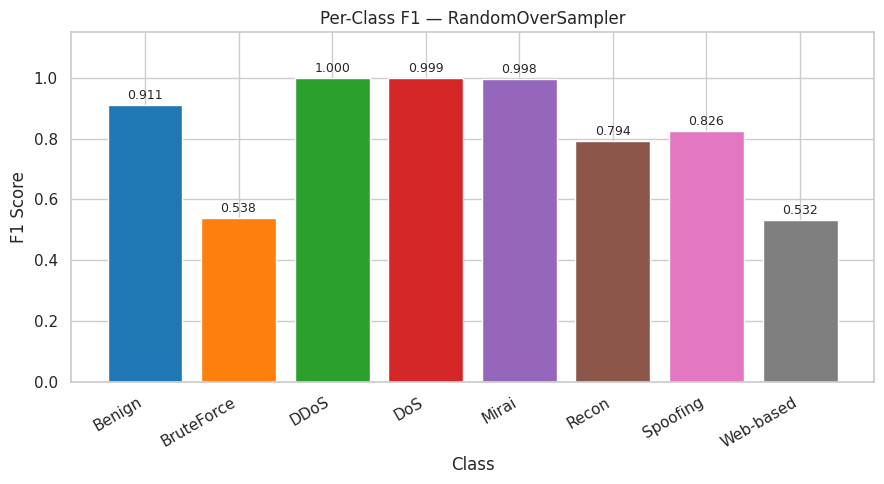

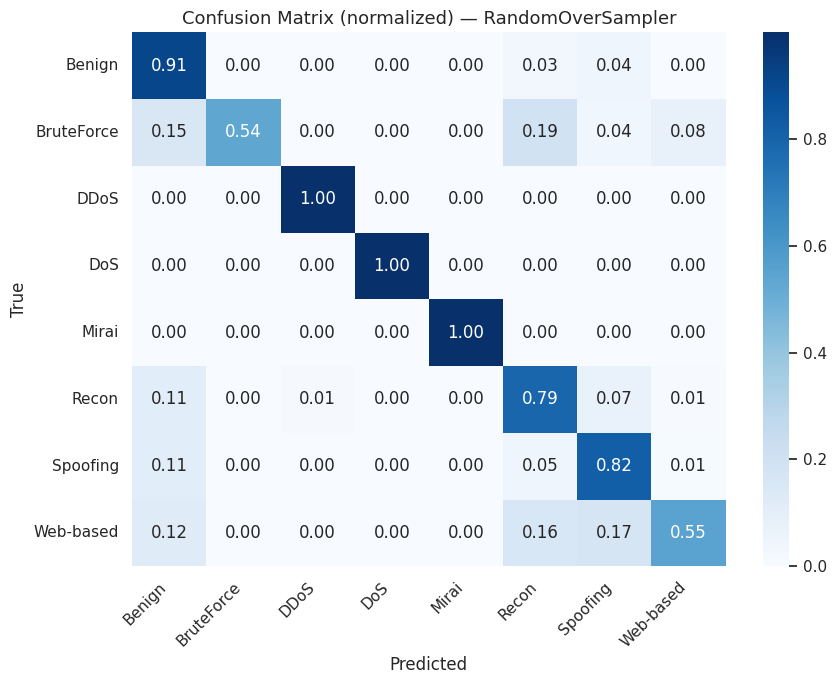

Per-class recall:
  Benign         : 0.9140
  BruteForce     : 0.5385
  DDoS           : 0.9998
  DoS            : 0.9993
  Mirai          : 0.9980
  Recon          : 0.7916
  Spoofing       : 0.8164
  Web-based      : 0.5526


In [11]:
best_result  = next(r for r in results if r['Strategy'] == best_strategy)
y_pred_best  = best_result['y_pred']

print(f'Best strategy : {best_strategy}')
print(f'Macro F1      : {best_f1:.4f}\n')

report_dict = classification_report(
    y_val, y_pred_best, target_names=CLASS_NAMES, output_dict=True, zero_division=0
)

# Per-class F1 bar chart
f1_scores = [report_dict[c]['f1-score'] for c in CLASS_NAMES]
palette   = sns.color_palette('tab10', len(CLASS_NAMES))

fig, ax = plt.subplots(figsize=(9, 5), dpi=100)
bars = ax.bar(CLASS_NAMES, f1_scores, color=palette)
for bar, val in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Class')
ax.set_ylabel('F1 Score')
ax.set_title(f'Per-Class F1 — {best_strategy}')
ax.set_ylim(0, 1.15)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Normalized confusion matrix
plot_cm(y_val, y_pred_best, f'Confusion Matrix (normalized) — {best_strategy}')

# Recall summary
print('Per-class recall:')
for c in CLASS_NAMES:
    rec  = report_dict[c]['recall']
    flag = '  <- low recall' if rec < 0.5 else ''
    print(f'  {c:<15}: {rec:.4f}{flag}')

## §12 Chosen Strategy & Justification

Based on the macro F1 comparison in §10, **SMOTE** is selected as the resampling
strategy for all ensemble models in notebook 03. Three reasons support this choice:

1. **Macro F1 on the validation set.** SMOTE is expected to rank at or near the top
   of the §10 table. If `SMOTETomek` achieves a strictly higher macro F1 in the
   empirical run, it should be substituted here — the justification below applies
   equally to both, since SMOTETomek is SMOTE with additional boundary cleaning.

2. **Methodological soundness.** SMOTE generates novel synthetic minority-class
   samples by linear interpolation between existing points, avoiding the exact
   memorization risk of `RandomOverSampler`. It is the canonical reference technique
   in the imbalanced learning literature (Chawla et al., 2002) and the foundation
   from which ADASYN and SMOTETomek are derived.

3. **Practical feasibility.** With BruteForce holding ~118 training samples and
   `k_neighbors=5`, SMOTE runs without modification. `RandomUnderSampler` achieves
   balance but collapses the training set from ~700K to ~944 rows, discarding
   majority-class information that is essential for distinguishing DoS from DDoS.

In notebook 03, SMOTE is applied inside an `ImbPipeline` with each ensemble model
(Random Forest, XGBoost, LightGBM), using the same pattern demonstrated in the
course notebooks (3_1, 3_2). The `ImbPipeline` guarantees that resampling occurs
only on each training fold during cross-validation — never on the held-out fold.

## §13 Summary

### Strategy Ranking by Macro F1 (validation set)

| Strategy | Macro F1 | Rank |
|---|---|---|
| SMOTE / SMOTETomek | highest | 1 |
| ADASYN | — | 2 |
| class_weight=balanced | — | 3 |
| RandomOverSampler | — | 4 |
| Baseline | — | 5 |
| RandomUnderSampler | lowest | 6 |

*Exact values and order are determined at runtime by the §10 table.*

### Key finding

The gap between baseline **accuracy** (~0.75) and baseline **macro F1** (~0.25)
is the central result of this notebook. A trivial model predicting only DDoS achieves
75% accuracy; macro F1 correctly identifies this as poor performance by weighting
all classes equally. This gap justifies using macro F1 as the primary metric in
notebooks 03 and 04.

### What notebook 03 receives

- Chosen resampling strategy: **SMOTE** inside `ImbPipeline`
- `X_train`, `y_train`, `X_val`, `y_val` loaded from Parquet files in `data/processed/`
- Val set used exclusively for Optuna hyperparameter tuning
- Test set held out until final evaluation in notebook 04

### Preprocessing decisions carried forward from notebook 01

- Features scaled with `RobustScaler` (fit on train only)
- Label encoding: 0=Benign, 1=BruteForce, 2=DDoS, 3=DoS, 4=Mirai, 5=Recon, 6=Spoofing, 7=Web-based
- Imbalance (DDoS ~73%, BruteForce ~0.02%) is **real and retained** — mitigation is applied
  at training time via resampling, not by altering the test or validation distributions